In [ ]:
#Program-1
import pandas as pd

data = pd.DataFrame([
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change', 'No'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change', 'Yes']
], columns=['Sky', 'AirTemp', 'Humidity', 'Wind', 'Water', 'Forecast', 'EnjoySport'])

print("Dataset:\n")
print(data)

attributes = data.columns[:-1]
target = data.columns[-1]

def find_s(df):
    hypothesis = ['0'] * (len(df.columns) - 1)
    for _, row in df.iterrows():
        if row[target] == "Yes":
            for j in range(len(hypothesis)):
                if hypothesis[j] == '0':
                    hypothesis[j] = row[j]
                elif hypothesis[j] != row[j]:
                    hypothesis[j] = '?'
    return hypothesis

final_hypothesis = find_s(data)
print("\nMost specific hypothesis (Find-S):")
print(final_hypothesis)

def candidate_elimination(df):
    S = [['0'] * (len(df.columns) - 1)]
    G = [['?'] * (len(df.columns) - 1)]

    for _, row in df.iterrows():
        if row[target] == "Yes":
            G = [g for g in G if all(
                g[j] == '?' or g[j] == row[j]
                for j in range(len(attributes))
            )]

            for j in range(len(attributes)):
                if S[0][j] == '0':
                    S[0][j] = row[j]
                elif S[0][j] != row[j]:
                    S[0][j] = '?'

        else:
            S = [s for s in S if not all(
                s[j] == '?' or s[j] == row[j]
                for j in range(len(attributes))
            )]

            new_G = []
            for g in G:
                for j in range(len(attributes)):
                    if g[j] == '?':
                        for val in df[attributes[j]].unique():
                            if val != row[j]:
                                new_hypo = g.copy()
                                new_hypo[j] = val
                                if any(all(
                                    new_hypo[k] == '?' or
                                    new_hypo[k] == s[k] or
                                    s[k] == '0'
                                    for k in range(len(attributes))
                                ) for s in S):
                                    new_G.append(new_hypo)
            G = new_G

    return S, G

S_final, G_final = candidate_elimination(data)

print("\nCandidate Elimination Results:")
print("S (Most Specific Boundary):", S_final)
print("G (Most General Boundary):", G_final)

Dataset:

     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes

Most specific hypothesis (Find-S):
['Sunny', 'Warm', '?', 'Strong', '?', '?']

Candidate Elimination Results:
S (Most Specific Boundary): [['Sunny', 'Warm', '?', 'Strong', '?', '?']]
G (Most General Boundary): [['Sunny', '?', '?', '?', '?', '?'], ['?', 'Warm', '?', '?', '?', '?']]


/tmp/ipykernel_12502/2694408637.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hypothesis[j] = row[j]
/tmp/ipykernel_12502/2694408637.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif hypothesis[j] != row[j]:
/tmp/ipykernel_12502/2694408637.py:45: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  S[0][j] = row[j]
/tmp/ipykernel_12502/2694408637.py:46: FutureWarning: Series.__getitem__ treating keys as positions is deprecat

In [ ]:
#Program-2
!pip install wittgenstein pandas scikit-learn

import pandas as pd
from sklearn.datasets import load_iris
import wittgenstein as lw

iris = load_iris(as_frame=True)

X = iris.data
y = iris.target

df = pd.concat([X, y.rename("target")], axis=1)

print("Dataset head:\n", df.head())

model = lw.RIPPER()

model.fit(X, y, pos_class=0)

print("\n=== RIPPER Rules ===")
print(model.ruleset_)

df_bin = df.copy()

df_bin['target'] = (df_bin['target'] == 0).astype(int)

attributes = list(X.columns)

def foil_gain(pos_before, neg_before, pos_after, neg_after):

    if pos_after == 0:
        return -1e9

    return pos_after * (
        (pos_after / (pos_after + neg_after)) -
        (pos_before / (pos_before + neg_before))
    )

def foil(df, target_col='target'):

    rules = []

    pos_total = df[target_col].sum()
    neg_total = len(df) - pos_total

    while pos_total > 0:

        rule = []

        pos_rem = pos_total
        neg_rem = neg_total

        covered = df.copy()

        while neg_rem > 0:

            best_gain = -1e9
            best_attr = None
            best_val = None
            best_subset = None

            for attr in attributes:

                for val in df[attr].unique():

                    subset = covered[covered[attr] == val]

                    pos_after = subset[target_col].sum()
                    neg_after = len(subset) - pos_after

                    gain = foil_gain(
                        pos_rem,
                        neg_rem,
                        pos_after,
                        neg_after
                    )

                    if gain > best_gain:
                        best_gain = gain
                        best_attr = attr
                        best_val = val
                        best_subset = subset

            if best_attr is None:
                break

            rule.append((best_attr, best_val))

            covered = best_subset

            pos_rem = covered[target_col].sum()
            neg_rem = len(covered) - pos_rem

        rules.append((rule, 1))

        df = df.drop(covered.index)

        pos_total = df[target_col].sum()
        neg_total = len(df) - pos_total

    return rules

rules = foil(df_bin)

print("\n=== FOIL Learned Rules (Setosa vs Not) ===")

for conds, pred in rules:

    cond_str = " AND ".join(
        [f"{a}={v}" for a, v in conds]
    )

    print(f"IF {cond_str} THEN class={pred}")

Dataset head:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

=== RIPPER Rules ===
[[petalwidth(cm)=<0.2] V [petalwidth(cm)=0.2-0.4] V [petallength(cm)=1.5-1.7]]

=== FOIL Learned Rules (Setosa vs Not) ===
IF petal width (cm)=0.2 THEN class=1
IF petal width (cm)=0.4 THEN class=1
IF petal width (cm)=0.3 THEN class=1
IF petal width (cm)=0.1 THEN class=1
IF sepal width (cm)=3.5 THEN class=1
IF petal length (cm)=1.7 THEN class=1


In [ ]:
#Program-3
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier,AdaBoostClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

data=load_breast_cancer()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target)
print("Dataset Shape:",X.shape)

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

bag_model=BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)
bag_model.fit(X_train,y_train)
y_pred_bag=bag_model.predict(X_test)

print("\n===Bagging Results===")
print("Accuracy:",accuracy_score(y_test,y_pred_bag))
print(classification_report(y_test,y_pred_bag))

boost_model=AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42
)
boost_model.fit(X_train,y_train)
y_pred_boost=boost_model.predict(X_test)

print("\n===Boosting Results(AdaBoost)===")
print("Accuracy:",accuracy_score(y_test,y_pred_boost))
print(classification_report(y_test,y_pred_boost))

print("\n Confusion Matrix-Bagging:\n",confusion_matrix(y_test,y_pred_bag))
print("\n Confusion Matrix-Boosting:\n",confusion_matrix(y_test,y_pred_boost))

Dataset Shape: (569, 30)

===Bagging Results===
Accuracy: 0.9415204678362573
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        64
           1       0.94      0.96      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171


===Boosting Results(AdaBoost)===
Accuracy: 0.9590643274853801
              precision    recall  f1-score   support

           0       0.98      0.91      0.94        64
           1       0.95      0.99      0.97       107

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171


 Confusion Matrix-Bagging:
 [[ 58   6]
 [  4 103]]

 Confusion Matrix-Boosting:
 [[ 58   6]
 [  1 106]]


Dataset Shape: (150, 4)

 Sample Clustered data:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  Cluster
0                5.1               3.5                1.4               0.2        1
1                4.9               3.0                1.4               0.2        1
2                4.7               3.2                1.3               0.2        1
3                4.6               3.1                1.5               0.2        1
4                5.0               3.6                1.4               0.2        1


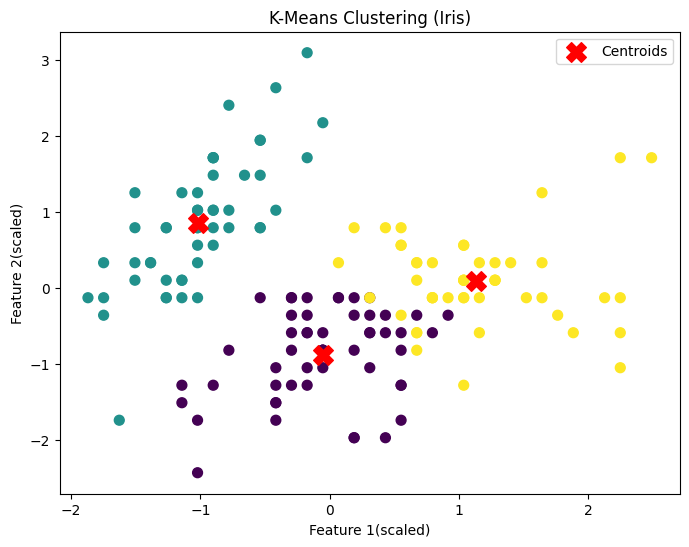

In [ ]:
#Program-4
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

iris = load_iris(as_frame=True)
X=iris.data

print("Dataset Shape:",X.shape)

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

k=3
kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
clusters=kmeans.fit_predict(X_scaled)

X_clustered=X.copy()
X_clustered['Cluster']=clusters

plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap='viridis',
    s=50
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)
print("\n Sample Clustered data:\n",X_clustered.head().to_string())
plt.title("K-Means Clustering (Iris)")
plt.xlabel("Feature 1(scaled)")
plt.ylabel("Feature 2(scaled)")
plt.legend()
plt.show()